# Millet Model

Architectural parameters
------------------------
  - $n$ : number of nodes in primary root 
  - $\delta$: reference distance between successive branching axis
  - $\beta$ : branching variability or Number of nodes between successive ramification
  - $order_{max}$ : maximum order of ramification
  - $\lambda$ : number of nodes in nude tip zone 
  - $radius$ : external radius of the main axis of the roots 
  - $crown\_length$ : length of crown roots
  - $crown\_nb$ : number of crown roots

In [1]:
#import and load pylab package
%pylab inline
%gui qt5

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
#Seminal
primary_length = 0.7
segment_length = 1.e-4
n = int(primary_length/segment_length)
nude_tip_length = (primary_length*0.15) / 0.75 # for a root 75cm-root we computed a 15cm nude tip length, so for a given root length we infer the corresponding length of apical zone
lamda = int(nude_tip_length/segment_length)
delta = 2.e-3 #branching rate
beta = 0.25
branching_delay = int(delta / segment_length)

#Crown root
crown_length = 0.12
m = int(crown_length/segment_length)
crown_nb = 2


Define a length law of LRs using equal amplitudes method from measured data
-----------------------------------------------------------------------------------

In [3]:
import numpy as np
import pandas as pd
from openalea.hydroroot.millet import architecture, water, display_millet,law, age
from openalea.hydroroot import radius
from openalea.hydroroot.display import plot
from openalea.plantgl.all import Viewer

In [4]:
filename = 'lr_length_law_data.csv'
xy = pd.read_csv(filename,sep=';')

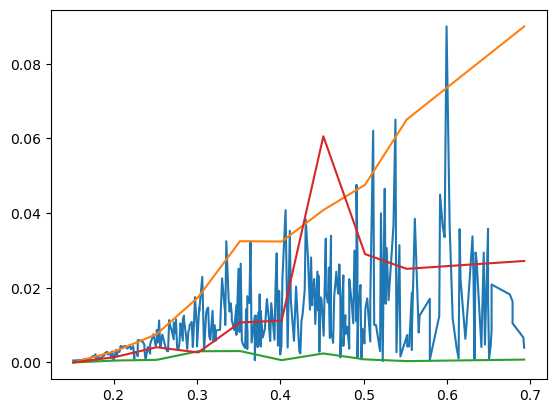

In [5]:
LR_length_law = law.expovariate_law(xy, size=5e-2, segment_length =1e-4, plot=True)

Compute architecture from architectural parameters $\&$ laws
------------------------------------------------------------------

In [6]:
#g = architecture.millet_mtg(LR_length_law = LR_length_law,nb_vertices=1500)
g = architecture.millet_mtg(nb_vertices = n,
                           nude_tip_length = lamda,
                           branching_delay = branching_delay,
                           crown_length = m,
                           nb_crown = crown_nb,
                           LR_length_law = LR_length_law
                           )

In [7]:
g = radius.compute_length(g)
g = radius.compute_relative_position(g)

Compute age of each vertex on the MTG
-----------------------------------------

* ### Define seminal root growth law

In [8]:
sr_growth_data = 'seminal_growth_109.csv'
pq = pd.read_csv(sr_growth_data, sep=';')

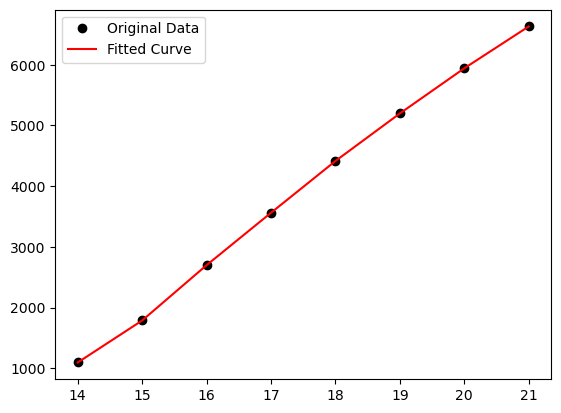

In [9]:
f = law.age_law(pq, segment_length = 1e-4,scale_x= 1, scale_y = 1.e-2, plot= True)

In [10]:
g = age.compute_age_with_constant_growth_speed(g)

In [11]:
plot(g, prop_cmap='age')

In [12]:
g = age.compute_age_with_constant_growth_speed_cpl(g)

### debug 15 0.0
### debug 15 5.05784887873161
### debug 15 5.089987144693615
### debug 15 5.134980717040422
### debug 15 5.184259391515497
### debug 15 5.224967861734037
### debug 15 5.282816740465647
### debug 15 5.3213826596200535
### debug 15 5.3578060277103265
### debug 15 5.41779745750607
### debug 15 5.456363376660477
### debug 15 5.497071846879017
### debug 15 5.554920725610628
### debug 15 5.582773889444367
### debug 15 5.6320525639194425
### debug 15 5.6899014426510535
### debug 15 5.724182259677193
### debug 15 5.771318383088136
### debug 15 5.812026853306677
### debug 15 5.854877874589352
### debug 15 5.912726753320963
### debug 15 5.957720325667772
### debug 15 5.996286244822179
### debug 15 6.041279817168988
### debug 15 6.084130838451663
### debug 15 6.137694615055007
### debug 15 6.176260534209414
### debug 15 6.227681759748624
### debug 15 6.2726753320954325
### debug 15 6.319811455506375
### debug 15 6.358377374660782
### debug 15 6.392658191686922
### debug 15 6.4505

Compute evolution laws of different root types diameter
--------------------------------------------------------------

* ###   Define evolution laws of radius of different root types

In [13]:
def func(k, a, b):
    return a * np.log(k) + b

In [14]:
#Estimate diameter law of seminal root
sr_data = 'SR_diameters.csv'
xy = pd.read_csv(sr_data, sep=';')

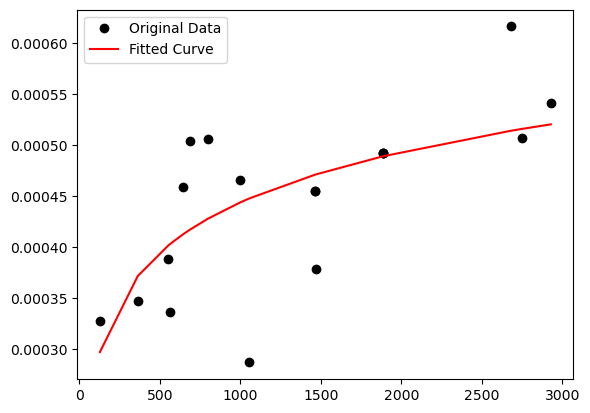

In [15]:
sr_diameter_law = law.diameter_law(xy,function=func, segment_length = 1e-4, plot= True)

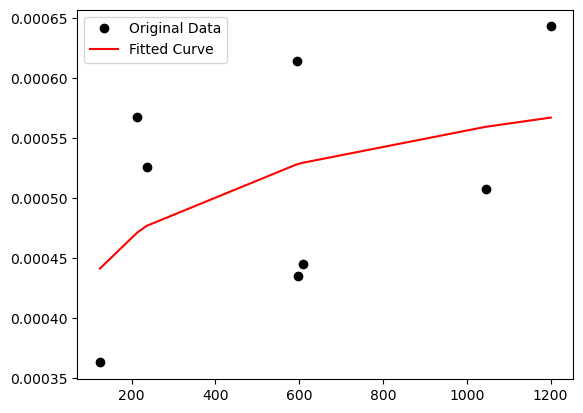

In [16]:
#Estimate diameter law of crown root
cr_data = 'CR_diameters.csv'
cr = pd.read_csv(cr_data, sep=';')
cr_diameter_law = law.diameter_law(cr,function=func, segment_length = 1e-4, plot= True)

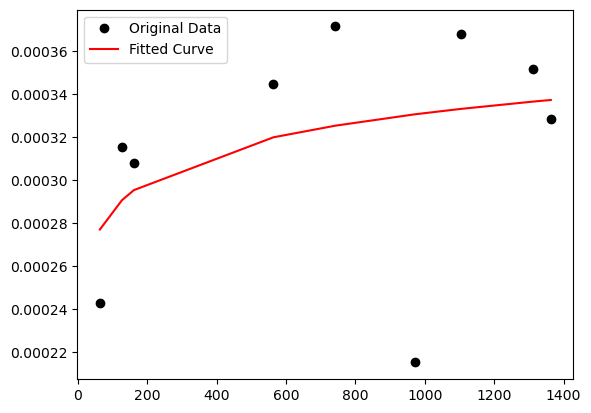

In [17]:
#Estimate diameter law of lateral root
lr_data = 'LR_diameters.csv'
ij = pd.read_csv(lr_data, sep=';')
lr_diameter_law = law.diameter_law(ij,function=func, segment_length = 1e-4, plot= True)

* ### Compute radius for different root types


In [18]:
g= radius.compute_length(g)
g = law.compute_radius_from_laws(g,seminal_RootDiameter_law = sr_diameter_law,
                                    crown_RootDiameter_law = cr_diameter_law,
                                    lr_RootDiameter_law = lr_diameter_law)

In [19]:
g, surface = radius.compute_surface(g)
g, volume = radius.compute_volume(g)

print('Surface : ', surface)
print('Volume : ', volume)

Surface :  0.011971059565453255
Volume :  2.073545283119896e-06


Visualize architectural model as a Multiscale Tree Graph (MTG)
----------------------------------------------------------------------

In [21]:
display_millet.plot_mtg(g,save_image = False,static = True)
# plot(g)

Use HydroRoot model to compute Water flux
==========================================

* ### Define hydraulic parameters

In [22]:
length_data = [0., 0.03, 0.05, 0.16], [0., 0., 0.01, 0.13]
radial_conductivity_data = (
    [0., 0.015, 0.03, 0.045, 0.06, 0.075, 0.09, 0.105, 0.135, 0.15, 0.16], 
    [300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300])


segment_length = 1e-4
ref_radius = 1e-4 # in m
order_decrease_factor = 0.7

# parameters
k0 = 300
Jv = 0.1
psi_e = 0.4
psi_base = 0.1


* ### Computation of Flux in millet root system

In [23]:
#Computation of g, surface, volume, Keq, Jv_global 

g, surface, volume, Keq, Jv_global = water.hydrolic(
    g,
    segment_length=segment_length,
    ref_radius = ref_radius,
    order_decrease_factor = order_decrease_factor,
    k0 = k0,
    Jv = Jv,
    psi_e = psi_e,
    psi_base = psi_base,
    length_data=length_data,
    axial_conductivity_data=None,
    radial_conductivity_data=radial_conductivity_data
    )


In [24]:
###### Test: plot properties

j = g.property('j')
K= g.property('K')

#scatter(j.values(),K.values())

print(g.property_names())

['edge_type', 'label', 'order', 'position_index', 'length', 'position', 'relative_position', 'age', 'radius', 'color', 'geometry', 'xyz', 'diam', 'K', 'k0', 'k', 'Keq', 'psi_in', 'psi_out', 'j', 'J_out']


Visualization of water fluxes in millet root system
==========================================

In [26]:
 # display_millet.plot_property(g,static=True, prop_cmap='j', lognorm = True)
 plot(g, prop_cmap='j', lognorm = True)

Add a Soil and compute $\Psi_e$
===============================

* ### Define a heterogeneous water soil potential

In [27]:

soil_potential = (
[0., 0.10, 0.5, 1.],
[0.1, 0.1, 0.4, 0.8]
)
x, y = soil_potential

g = law.add_soil(g, soil_potential)

* ### Compute water flux on soil

In [28]:
g, surface, volume, Keq, Jv_global = water.hydrolic(
    g,
    segment_length=segment_length,
    ref_radius = ref_radius,
    order_decrease_factor = order_decrease_factor,
    k0 = k0,
    Jv = Jv,
    psi_e = None,
    psi_base = psi_base,
    length_data=length_data,
    axial_conductivity_data=None,
    radial_conductivity_data=radial_conductivity_data
    )


In [30]:
plot(g, prop_cmap='j', lognorm = True)